In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patheffects import withStroke
import geopandas as gpd
from netCDF4 import Dataset
import os
import cv2
import datetime
import numba

In [2]:
data = pd.read_csv('1980_2013_2014.csv')
print(data.head())

     Year  Month  Day  Longitude  Latitude  ProfileNumber     Dataset  \
0  1980.0    1.0  5.0   159.8000   29.5300       359587.0  Hydrobase3   
1  1980.0    1.0  5.0   159.8000   29.5330       359588.0  Hydrobase3   
2  1980.0    1.0  5.0   159.8000   29.5333       227346.0     WOD_OSD   
3  1980.0    1.0  5.0   159.9667   30.0500       227352.0     WOD_OSD   
4  1980.0    1.0  5.0   159.9670   30.0500       359589.0  Hydrobase3   

   DO_mean(umol/kg)  DO_min(umol/kg)  DO_max(umol/kg)  Depth_min(m)  \
0        207.727273        83.900000       224.500000           0.0   
1        183.855556        53.900000       224.900000           0.0   
2        183.913809        54.026798       224.821198           0.0   
3        181.730468        47.055603       226.128296           0.0   
4        181.650000        46.900000       226.100000           0.0   

   Depth_max(m)  
0         900.0  
1        1045.0  
2        1045.0  
3        1142.0  
4        1142.0  


In [3]:
filtered_data = data[(data['Year'] == 2013) | (data['Year'] == 2014)]
print(filtered_data)

         Year  Month   Day  Longitude  Latitude  ProfileNumber  Dataset  \
1729   2013.0    1.0   1.0    141.980    34.196       102527.0     argo   
1730   2013.0    1.0   1.0    143.216    37.793        49364.0  WOD_PFL   
1731   2013.0    1.0   1.0    143.216    37.793       102699.0     argo   
1732   2013.0    1.0   1.0    143.547    37.393        49425.0  WOD_PFL   
1733   2013.0    1.0   1.0    143.547    37.393       112948.0     argo   
...       ...    ...   ...        ...       ...            ...      ...   
10970  2014.0   12.0  31.0    141.350    31.273        26496.0  WOD_PFL   
10971  2014.0   12.0  31.0    152.553    39.596       143522.0     argo   
10972  2014.0   12.0  31.0    154.866    30.377       145337.0     argo   
10973  2014.0   12.0  31.0    155.887    34.292       114372.0     argo   
10974  2014.0   12.0  31.0    160.553    33.209       103066.0     argo   

       DO_mean(umol/kg)  DO_min(umol/kg)  DO_max(umol/kg)  Depth_min(m)  \
1729         137.867478 

In [4]:
SLA=Dataset('../EddyNet/cmems_2019-01-01~2019-12-31.nc')
maplon=SLA.variables['longitude'][:]
maplon=maplon[1:] #输入的ground truth是(81,180)，也就是maplon缺少了头上一位
maplat=SLA.variables['latitude'][:]

In [5]:
AC_eddy_truth=np.load('../EddyNet/Eddy Statistics/Data/AC_eddy_truth.npy')
C_eddy_truth=np.load('../EddyNet/Eddy Statistics/Data/C_eddy_truth.npy')

In [6]:
(datetime.datetime.fromtimestamp(915120000)+datetime.timedelta(days=0)).strftime('%Y-%m-%d')

'1999-01-01'

In [7]:
is_eddy=[]
for i in range(len(filtered_data)):
    timestamp = datetime.datetime(filtered_data.iloc[i]['Year'].astype(int),
                                    filtered_data.iloc[i]['Month'].astype(int),
                                    filtered_data.iloc[i]['Day'].astype(int))
    time = (timestamp - datetime.datetime.fromtimestamp(915120000)).days
    lat = filtered_data.iloc[i]['Latitude']
    lon = filtered_data.iloc[i]['Longitude']
    lat_idx = (np.abs(maplat - lat)).argmin()
    lon_idx = (np.abs(maplon - lon)).argmin()
    if np.abs(maplat[lat_idx]-lat)>0.5 or np.abs(maplon[lon_idx]-lon)>0.5:
        print('Error: lat or lon is too far from the nearest grid point')
        continue
    if AC_eddy_truth[time,lat_idx,lon_idx]!=0:
        is_eddy.append(1)
        continue
    if C_eddy_truth[time,lat_idx,lon_idx]!=0:
        is_eddy.append(2)
        continue
    is_eddy.append(0)

is_eddy = np.array(is_eddy)

In [8]:
new_filtered_data = filtered_data.copy()
new_filtered_data['Eddy'] = ['AC' if x == 1 else 'C' if x == 2 else 'None' for x in is_eddy]

new_filtered_data.to_csv('output.csv', index=False)

# Track

In [8]:
new_filtered_data = pd.read_csv('output.csv')

In [9]:
AC_truth_stats_area=np.load('../EddyNet/Eddy Statistics/Data/AC_truth_stats_area.npy',allow_pickle=True)
AC_truth_stats_center=np.load('../EddyNet/Eddy Statistics/Data/AC_truth_stats_center.npy',allow_pickle=True)
C_truth_stats_area=np.load('../EddyNet/Eddy Statistics/Data/C_truth_stats_area.npy',allow_pickle=True)
C_truth_stats_center=np.load('../EddyNet/Eddy Statistics/Data/C_truth_stats_center.npy',allow_pickle=True)

AC_truth_stats_area=AC_truth_stats_area.tolist()
AC_truth_stats_center=AC_truth_stats_center.tolist()
C_truth_stats_area=C_truth_stats_area.tolist()
C_truth_stats_center=C_truth_stats_center.tolist()

AC_truth_tracks_filtered=np.load('../EddyNet/Eddy Statistics/Data/AC_truth_tracks_filtered.npy',allow_pickle=True)
C_truth_tracks_filtered=np.load('../EddyNet/Eddy Statistics/Data/C_truth_tracks_filtered.npy',allow_pickle=True)

AC_truth_tracks_filtered=AC_truth_tracks_filtered.tolist()
C_truth_tracks_filtered=C_truth_tracks_filtered.tolist()


In [10]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

/var/folders/69/_jw_j6yj01b559dqr0mh0njm0000gn/T/ipykernel_81960/208474226.py:2: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


## Year

In [12]:
traj_AC=[]
for track in AC_truth_tracks_filtered:
    traj_x=[]
    traj_y=[]
    exist_time=AC_truth_tracks_filtered[track][-1][0]-AC_truth_tracks_filtered[track][0][0]+1
    # if exist_time<100:
    #     continue
    for i in range(len(AC_truth_tracks_filtered[track])):
        eddy_date,eddy_num=AC_truth_tracks_filtered[track][i]
        timestamp = datetime.datetime.fromtimestamp(915120000)+datetime.timedelta(days=eddy_date)
        if timestamp.year!=2013 and timestamp.year!=2014:
            continue
        x=AC_truth_stats_center[eddy_date][eddy_num][1]*0.25+135.125
        y=44.875-AC_truth_stats_center[eddy_date][eddy_num][0]*0.25

        traj_x.append(x)
        traj_y.append(y)
    if len(traj_x)>0:
        traj_AC.append([traj_x,traj_y])

traj_C=[]
for track in C_truth_tracks_filtered:
    traj_x=[]
    traj_y=[]
    exist_time=C_truth_tracks_filtered[track][-1][0]-C_truth_tracks_filtered[track][0][0]+1
    # if exist_time<100:
    #     continue
    for i in range(len(C_truth_tracks_filtered[track])):
        eddy_date,eddy_num=C_truth_tracks_filtered[track][i]
        timestamp = datetime.datetime.fromtimestamp(915120000)+datetime.timedelta(days=eddy_date)
        if timestamp.year!=2013 and timestamp.year!=2014:
            continue
        x=C_truth_stats_center[eddy_date][eddy_num][1]*0.25+135.125
        y=44.875-C_truth_stats_center[eddy_date][eddy_num][0]*0.25

        traj_x.append(x)
        traj_y.append(y)
    if len(traj_x)>0:
        traj_C.append([traj_x,traj_y])

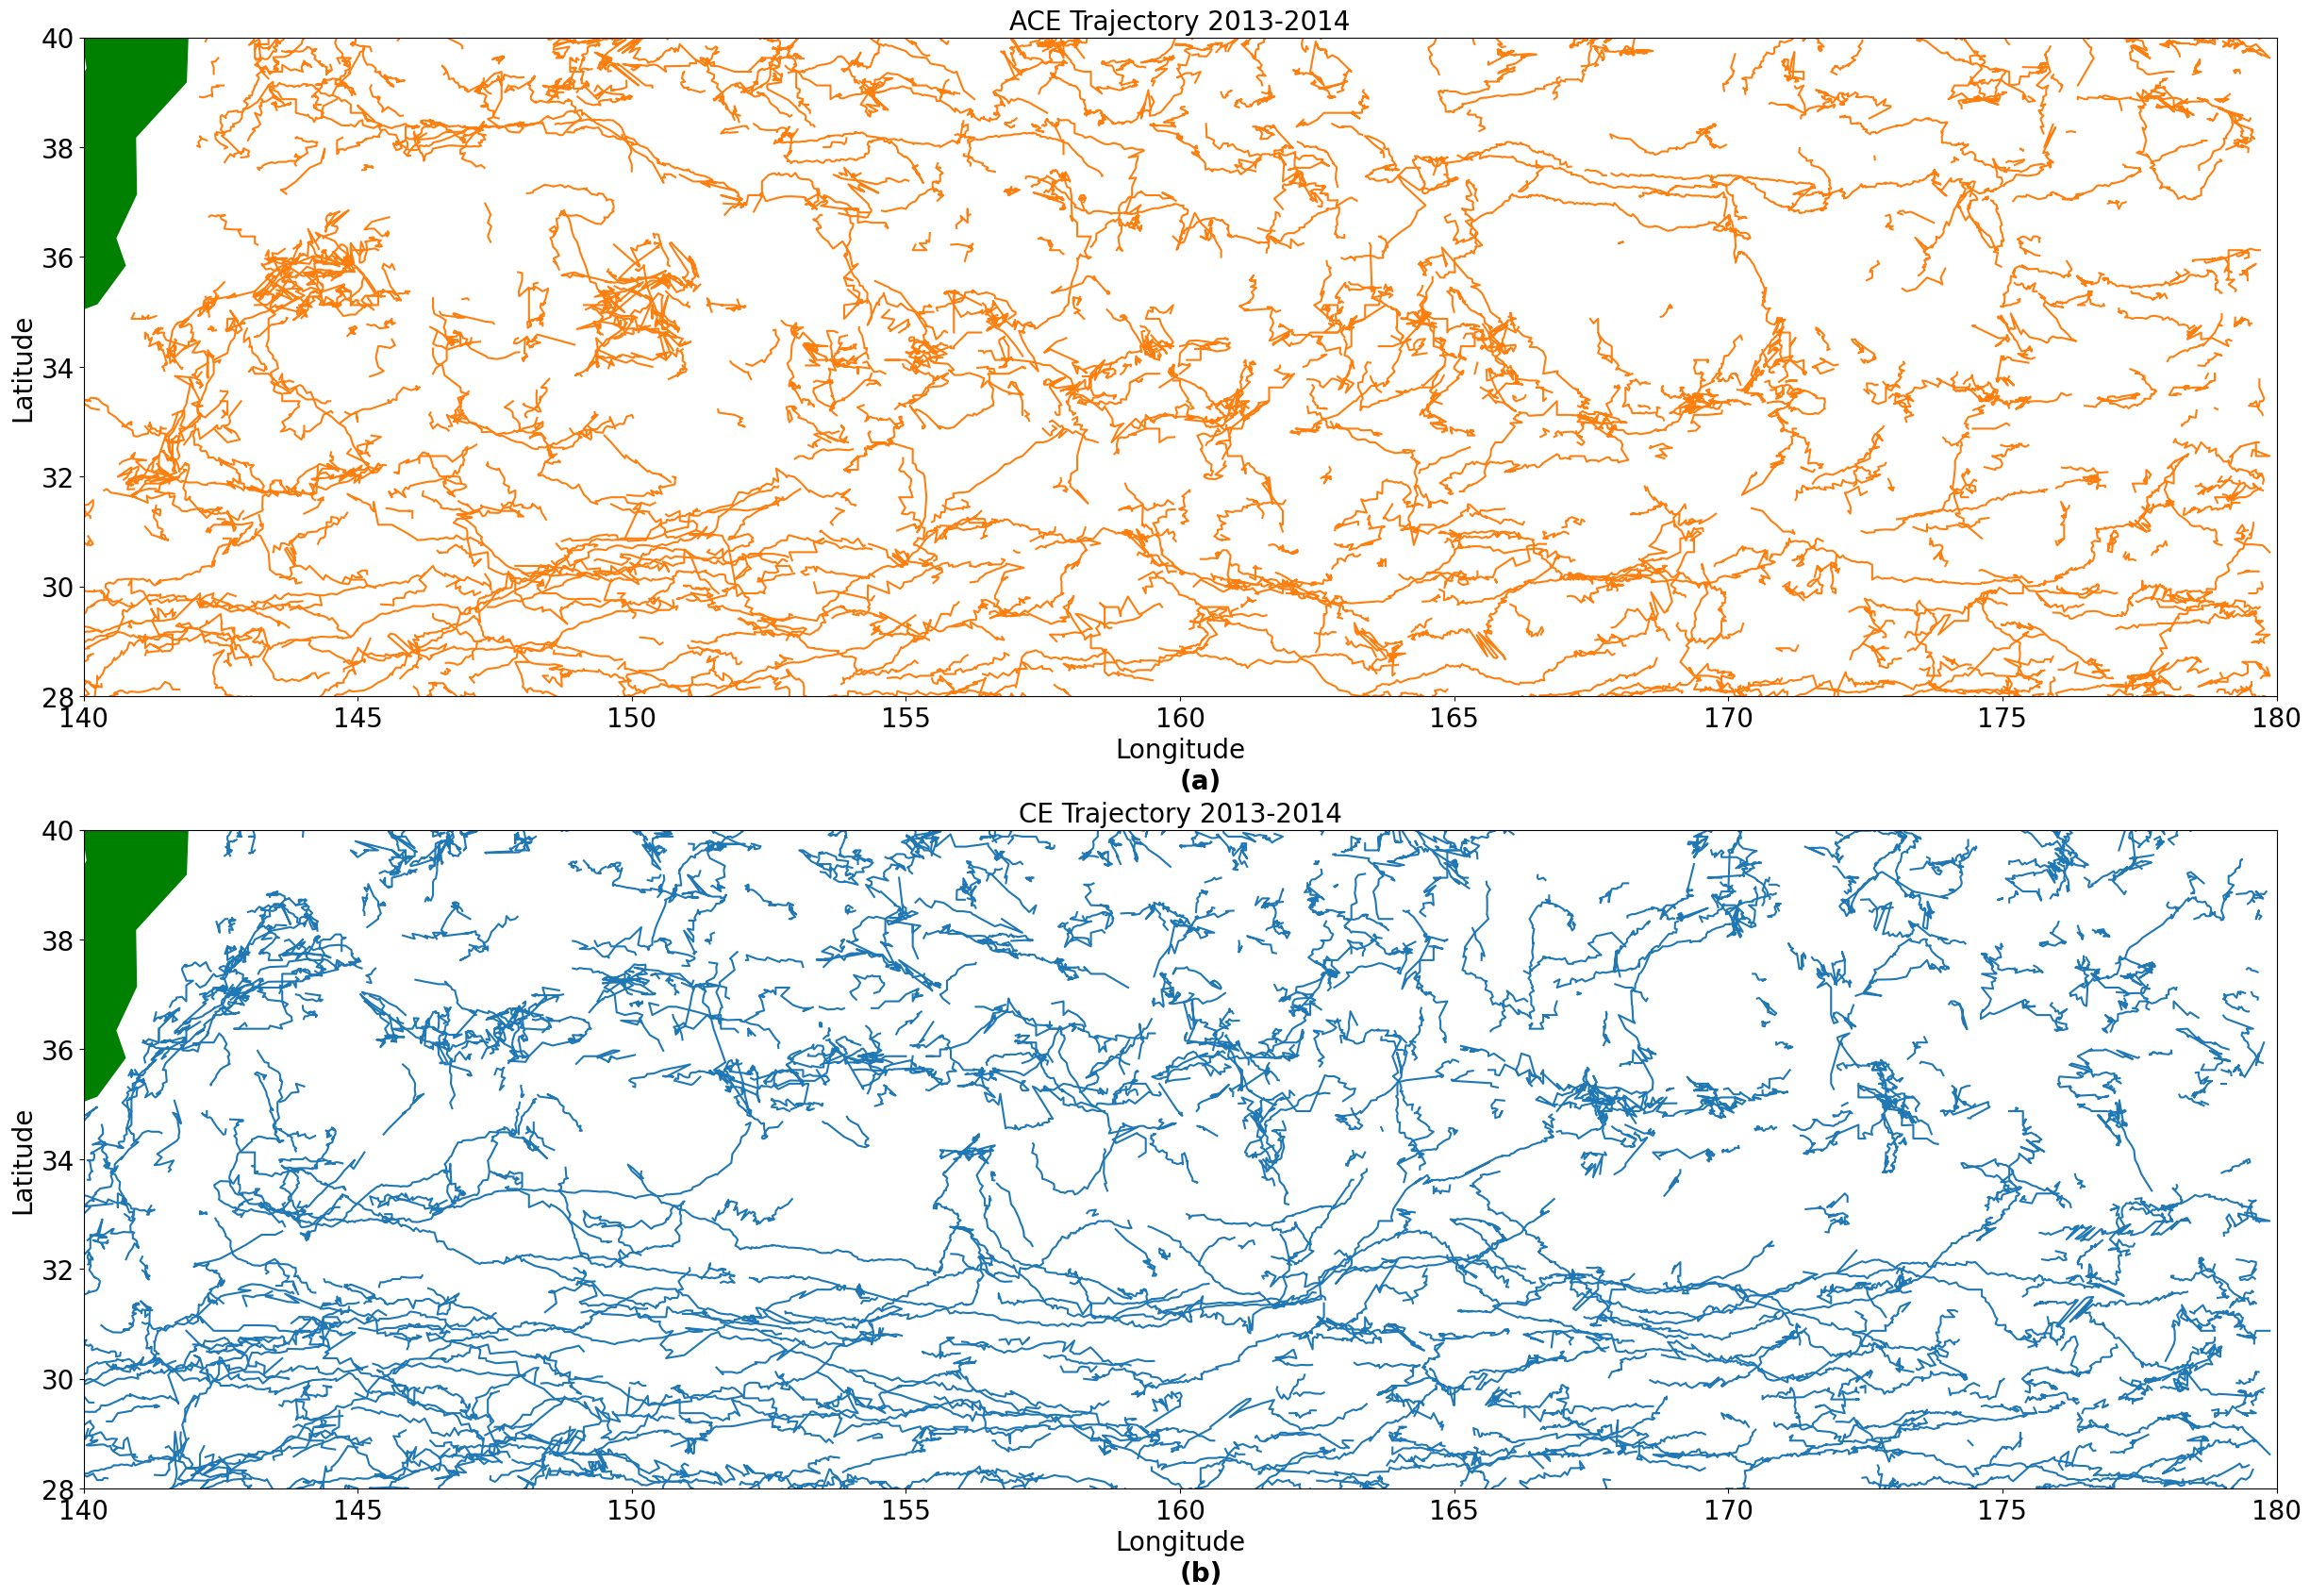

In [13]:
fig, axs = plt.subplots(2, 1, figsize=(30, 20))

# 第一个subplot
axs[0].set_title('ACE Trajectory 2013-2014', fontsize=20)
axs[0].set_xlabel('Longitude', fontsize=20)
axs[0].set_ylabel('Latitude', fontsize=20)
axs[0].text(0.5, -0.14, '(a)', transform=axs[0].transAxes, size=20,weight='bold')
world.plot(color='green', ax=axs[0])
axs[0].set_xlim([140, 180])
axs[0].set_ylim([28, 40])
for traj in traj_AC:
    axs[0].plot(traj[0],traj[1],color=colors[1])
axs[0].tick_params(axis='both', which='major', labelsize=20)

# 第二个subplot
axs[1].set_title('CE Trajectory 2013-2014', fontsize=20)
axs[1].set_xlabel('Longitude', fontsize=20)
axs[1].set_ylabel('Latitude', fontsize=20)
axs[1].text(0.5, -0.14, '(b)', transform=axs[1].transAxes, size=20,weight='bold')
world.plot(color='green', ax=axs[1])
axs[1].set_xlim([140, 180])
axs[1].set_ylim([28, 40])
for traj in traj_C:
    axs[1].plot(traj[0],traj[1],color=colors[0])
axs[1].tick_params(axis='both', which='major', labelsize=20)

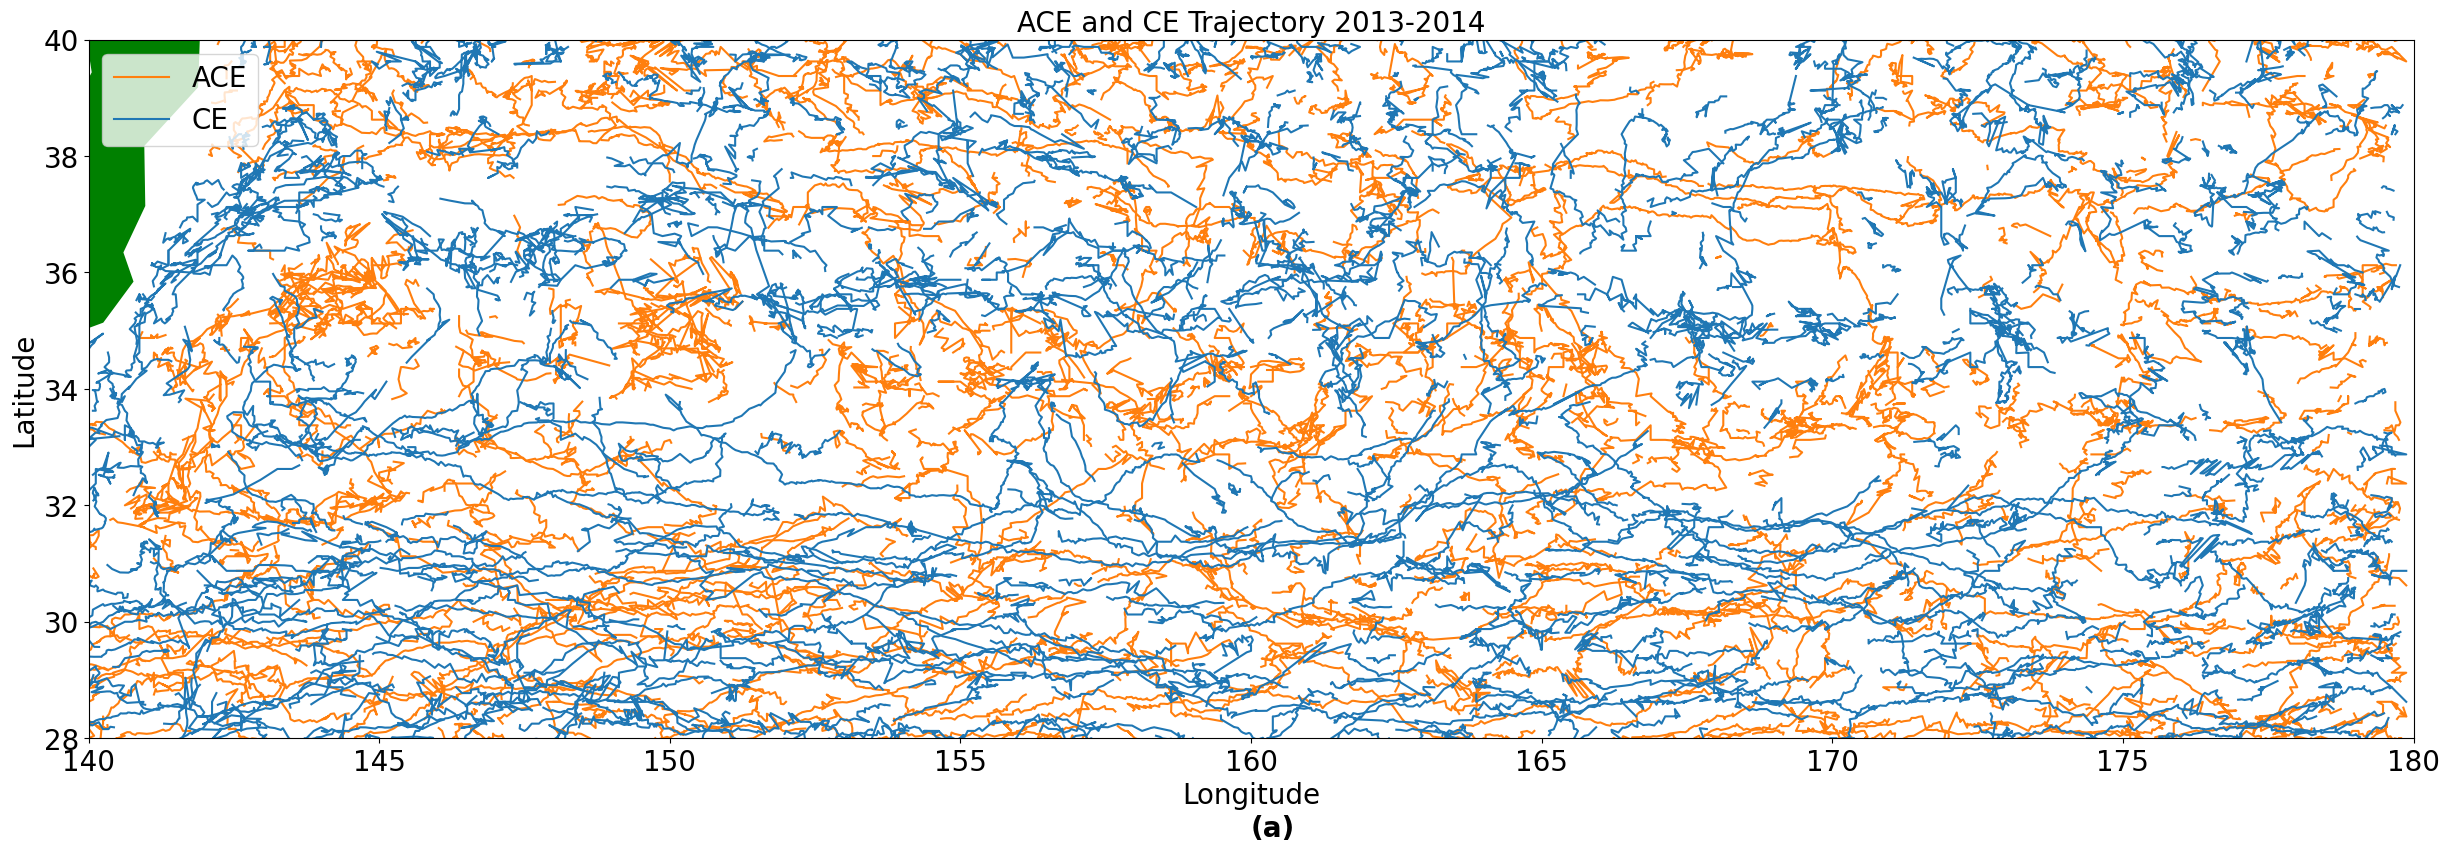

In [14]:
fig, ax = plt.subplots(figsize=(30, 20))

ax.set_title('ACE and CE Trajectory 2013-2014', fontsize=20)
ax.set_xlabel('Longitude', fontsize=20)
ax.set_ylabel('Latitude', fontsize=20)
ax.text(0.5, -0.14, '(a)', transform=ax.transAxes, size=20, weight='bold')
world.plot(color='green', ax=ax)
ax.set_xlim([140, 180])
ax.set_ylim([28, 40])

# 绘制ACE轨迹
for traj in traj_AC:
    ax.plot(traj[0], traj[1], color=colors[1], label='ACE' if traj == traj_AC[0] else "")

# 绘制CE轨迹
for traj in traj_C:
    ax.plot(traj[0], traj[1], color=colors[0], label='CE' if traj == traj_C[0] else "")

ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend(fontsize=20)

## Monthly

In [11]:
new_filtered_data.iloc[1]

Year                    2013.0
Month                      1.0
Day                        1.0
Longitude              143.216
Latitude                37.793
ProfileNumber          49364.0
Dataset                WOD_PFL
DO_mean(umol/kg)    128.568724
DO_min(umol/kg)        28.2332
DO_max(umol/kg)     211.508408
Depth_min(m)           4.36711
Depth_max(m)        989.953552
Eddy                         C
Name: 1, dtype: object

In [ ]:
import os

# 创建保存图像的文件夹
output_dir = 'monthly_trajectories'
os.makedirs(output_dir, exist_ok=True)

# 定义年份和月份范围
years = [2013, 2014]
months = range(1, 13)

for year in years:
    for month in months:
        traj_AC = []
        for track in AC_truth_tracks_filtered:
            traj_x = []
            traj_y = []
            for i in range(len(AC_truth_tracks_filtered[track])):
                eddy_date, eddy_num = AC_truth_tracks_filtered[track][i]
                timestamp = datetime.datetime.fromtimestamp(915120000) + datetime.timedelta(days=eddy_date)
                if timestamp.year == year and timestamp.month == month:
                    x = AC_truth_stats_center[eddy_date][eddy_num][1] * 0.25 + 135.125
                    y = 44.875 - AC_truth_stats_center[eddy_date][eddy_num][0] * 0.25
                    traj_x.append(x)
                    traj_y.append(y)
            if len(traj_x) > 0:
                traj_AC.append([traj_x, traj_y])

        traj_C = []
        for track in C_truth_tracks_filtered:
            traj_x = []
            traj_y = []
            for i in range(len(C_truth_tracks_filtered[track])):
                eddy_date, eddy_num = C_truth_tracks_filtered[track][i]
                timestamp = datetime.datetime.fromtimestamp(915120000) + datetime.timedelta(days=eddy_date)
                if timestamp.year == year and timestamp.month == month:
                    x = C_truth_stats_center[eddy_date][eddy_num][1] * 0.25 + 135.125
                    y = 44.875 - C_truth_stats_center[eddy_date][eddy_num][0] * 0.25
                    traj_x.append(x)
                    traj_y.append(y)
            if len(traj_x) > 0:
                traj_C.append([traj_x, traj_y])

        fig, ax = plt.subplots(figsize=(30, 20))
        ax.set_title(f'ACE and CE Trajectory {year}.{month:02d}', fontsize=20)
        ax.set_xlabel('Longitude', fontsize=20)
        ax.set_ylabel('Latitude', fontsize=20)
        ax.text(0.5, -0.14, '(a)', transform=ax.transAxes, size=20, weight='bold')
        world.plot(color='green', ax=ax)
        ax.set_xlim([140, 180])
        ax.set_ylim([28, 40])

        # 绘制ACE轨迹
        for traj in traj_AC:
            ax.plot(traj[0], traj[1], color=colors[1], label='ACE' if traj == traj_AC[0] else "")

        # 绘制CE轨迹
        for traj in traj_C:
            ax.plot(traj[0], traj[1], color=colors[0], label='CE' if traj == traj_C[0] else "")

        # 绘制观测站点
        month_data = new_filtered_data[(new_filtered_data['Year'] == year) & (new_filtered_data['Month'] == month)]
        ax.scatter(month_data['Longitude'], month_data['Latitude'], color='purple', s=50, label='Observation Points')

        ax.tick_params(axis='both', which='major', labelsize=20)
        ax.legend(fontsize=20, loc='upper left')

        # 保存图像
        output_path = os.path.join(output_dir, f'trajectory_{year}_{month:02d}.png')
        fig.savefig(output_path)
        plt.close(fig)

In [ ]:
import os

# 创建保存图像的文件夹
output_dir = 'monthly_trajectories'
os.makedirs(output_dir, exist_ok=True)

# 定义年份和月份范围
years = [2013, 2014]
months = range(1, 13)

for year in years:
    for month in months:
        traj_AC = []
        for track in AC_truth_tracks_filtered:
            traj_x = []
            traj_y = []
            traj_r = []
            for i in range(len(AC_truth_tracks_filtered[track])):
                eddy_date, eddy_num = AC_truth_tracks_filtered[track][i]
                timestamp = datetime.datetime.fromtimestamp(915120000) + datetime.timedelta(days=eddy_date)
                if timestamp.year == year and timestamp.month == month:
                    x = AC_truth_stats_center[eddy_date][eddy_num][1] * 0.25 + 135.125
                    y = 44.875 - AC_truth_stats_center[eddy_date][eddy_num][0] * 0.25
                    r = np.sqrt(AC_truth_stats_area[eddy_date][eddy_num] / np.pi) * 0.25
                    traj_x.append(x)
                    traj_y.append(y)
                    traj_r.append(r)
            if len(traj_x) > 0:
                traj_AC.append([traj_x, traj_y, traj_r])

        traj_C = []
        for track in C_truth_tracks_filtered:
            traj_x = []
            traj_y = []
            traj_r = []
            for i in range(len(C_truth_tracks_filtered[track])):
                eddy_date, eddy_num = C_truth_tracks_filtered[track][i]
                timestamp = datetime.datetime.fromtimestamp(915120000) + datetime.timedelta(days=eddy_date)
                if timestamp.year == year and timestamp.month == month:
                    x = C_truth_stats_center[eddy_date][eddy_num][1] * 0.25 + 135.125
                    y = 44.875 - C_truth_stats_center[eddy_date][eddy_num][0] * 0.25
                    r = np.sqrt(C_truth_stats_area[eddy_date][eddy_num] / np.pi) * 0.25
                    traj_x.append(x)
                    traj_y.append(y)
                    traj_r.append(r)
            if len(traj_x) > 0:
                traj_C.append([traj_x, traj_y, traj_r])

        fig, ax = plt.subplots(figsize=(30, 20))
        ax.set_title(f'ACE and CE Trajectory {year}.{month:02d}', fontsize=20)
        ax.set_xlabel('Longitude', fontsize=20)
        ax.set_ylabel('Latitude', fontsize=20)
        ax.text(0.5, -0.14, '(a)', transform=ax.transAxes, size=20, weight='bold')
        world.plot(color='green', ax=ax)
        ax.set_xlim([140, 180])
        ax.set_ylim([28, 40])

        # 绘制ACE轨迹
        for traj in traj_AC:
            for x, y, r in zip(traj[0], traj[1], traj[2]):
                circle = plt.Circle((x, y), r, color=colors[1], fill=False, alpha=0.5)
                ax.add_patch(circle)
            ax.plot(traj[0], traj[1], color=colors[1], label='ACE' if traj == traj_AC[0] else "")

        # 绘制CE轨迹
        for traj in traj_C:
            for x, y, r in zip(traj[0], traj[1], traj[2]):
                circle = plt.Circle((x, y), r, color=colors[0], fill=False, alpha=0.5)
                ax.add_patch(circle)
            ax.plot(traj[0], traj[1], color=colors[0], label='CE' if traj == traj_C[0] else "")

        # 绘制观测站点
        month_data = new_filtered_data[(new_filtered_data['Year'] == year) & (new_filtered_data['Month'] == month)]
        ax.scatter(month_data['Longitude'], month_data['Latitude'], color='purple', s=50, label='Observation Points')

        ax.tick_params(axis='both', which='major', labelsize=20)
        ax.legend(fontsize=20, loc='upper left')

        # 保存图像
        output_path = os.path.join(output_dir, f'trajectory_{year}_{month:02d}.png')
        fig.savefig(output_path)
        plt.close(fig)

In [24]:
import os

# 创建保存图像的文件夹
output_dir = 'monthly_trajectories'
os.makedirs(output_dir, exist_ok=True)

# 定义年份和月份范围
years = [2013, 2014]
months = range(1, 13)

for year in years:
    for month in months:
        traj_AC = []
        for track in AC_truth_tracks_filtered:
            traj_x = []
            traj_y = []
            traj_r = []
            for i in range(len(AC_truth_tracks_filtered[track])):
                eddy_date, eddy_num = AC_truth_tracks_filtered[track][i]
                timestamp = datetime.datetime.fromtimestamp(915120000) + datetime.timedelta(days=eddy_date)
                if timestamp.year == year and timestamp.month == month:
                    x = AC_truth_stats_center[eddy_date][eddy_num][1] * 0.25 + 135.125
                    y = 44.875 - AC_truth_stats_center[eddy_date][eddy_num][0] * 0.25
                    r = np.sqrt(AC_truth_stats_area[eddy_date][eddy_num] / np.pi) * 0.25
                    traj_x.append(x)
                    traj_y.append(y)
                    traj_r.append(r)
            if len(traj_x) > 0:
                traj_AC.append([traj_x, traj_y, traj_r,track])

        traj_C = []
        for track in C_truth_tracks_filtered:
            traj_x = []
            traj_y = []
            traj_r = []
            for i in range(len(C_truth_tracks_filtered[track])):
                eddy_date, eddy_num = C_truth_tracks_filtered[track][i]
                timestamp = datetime.datetime.fromtimestamp(915120000) + datetime.timedelta(days=eddy_date)
                if timestamp.year == year and timestamp.month == month:
                    x = C_truth_stats_center[eddy_date][eddy_num][1] * 0.25 + 135.125
                    y = 44.875 - C_truth_stats_center[eddy_date][eddy_num][0] * 0.25
                    r = np.sqrt(C_truth_stats_area[eddy_date][eddy_num] / np.pi) * 0.25
                    traj_x.append(x)
                    traj_y.append(y)
                    traj_r.append(r)
            if len(traj_x) > 0:
                traj_C.append([traj_x, traj_y, traj_r,track])

        fig, ax = plt.subplots(figsize=(30, 20))
        ax.set_title(f'ACE and CE Trajectory {year}.{month:02d}', fontsize=20)
        ax.set_xlabel('Longitude', fontsize=20)
        ax.set_ylabel('Latitude', fontsize=20)
        ax.text(0.5, -0.14, '(a)', transform=ax.transAxes, size=20, weight='bold')
        world.plot(color='green', ax=ax)
        ax.set_xlim([140, 180])
        ax.set_ylim([28, 40])

        # 绘制ACE轨迹
        for traj in traj_AC:
            for x, y, r in zip(traj[0], traj[1], traj[2]):
                circle = plt.Circle((x, y), r, color=colors[1], fill=False, alpha=0.5)
                ax.add_patch(circle)
            ax.plot(traj[0], traj[1], color=colors[1], label='ACE' if traj == traj_AC[0] else "")
            if 140 <= traj[0][0] <= 180 and 28 <= traj[1][0] <= 40:
                ax.text(traj[0][0], traj[1][0], str(traj[3]), fontsize=12, color='black')
            

        # 绘制CE轨迹
        for traj in traj_C:
            for x, y, r in zip(traj[0], traj[1], traj[2]):
                circle = plt.Circle((x, y), r, color=colors[0], fill=False, alpha=0.5)
                ax.add_patch(circle)
            ax.plot(traj[0], traj[1], color=colors[0], label='CE' if traj == traj_C[0] else "")
            if 140 <= traj[0][0] <= 180 and 28 <= traj[1][0] <= 40:
                ax.text(traj[0][0], traj[1][0], str(traj[3]), fontsize=12, color='black')

        # 绘制观测站点
        month_data = new_filtered_data[(new_filtered_data['Year'] == year) & (new_filtered_data['Month'] == month)]
        ax.scatter(month_data['Longitude'], month_data['Latitude'], color='purple', s=50, label='Observation Points')

        ax.tick_params(axis='both', which='major', labelsize=20)
        ax.legend(fontsize=20, loc='upper left')

        # 保存图像
        output_path = os.path.join(output_dir, f'trajectory_{year}_{month:02d}.png')
        fig.savefig(output_path)
        plt.close(fig)

In [21]:
traj_AC[0][3]

10807

# Export Track

In [18]:
AC_truth_stats_area=np.load('../EddyNet/Eddy Statistics/Data/AC_truth_stats_area.npy',allow_pickle=True)
AC_truth_stats_center=np.load('../EddyNet/Eddy Statistics/Data/AC_truth_stats_center.npy',allow_pickle=True)
C_truth_stats_area=np.load('../EddyNet/Eddy Statistics/Data/C_truth_stats_area.npy',allow_pickle=True)
C_truth_stats_center=np.load('../EddyNet/Eddy Statistics/Data/C_truth_stats_center.npy',allow_pickle=True)

AC_truth_stats_area=AC_truth_stats_area.tolist()
AC_truth_stats_center=AC_truth_stats_center.tolist()
C_truth_stats_area=C_truth_stats_area.tolist()
C_truth_stats_center=C_truth_stats_center.tolist()

AC_truth_tracks_filtered=np.load('../EddyNet/Eddy Statistics/Data/AC_truth_tracks_filtered.npy',allow_pickle=True)
C_truth_tracks_filtered=np.load('../EddyNet/Eddy Statistics/Data/C_truth_tracks_filtered.npy',allow_pickle=True)

AC_truth_tracks_filtered=AC_truth_tracks_filtered.tolist()
C_truth_tracks_filtered=C_truth_tracks_filtered.tolist()

AC_truth_detected_numbered=np.load('../EddyNet/Eddy Statistics/Data/AC_truth_detected_numbered.npy')
C_truth_detected_numbered=np.load('../EddyNet/Eddy Statistics/Data/C_truth_detected_numbered.npy')

In [48]:
traj_AC = []
traj_C = []

for year in years:
    for month in months:
        for track in AC_truth_tracks_filtered:
            traj_x = []
            traj_y = []
            traj_r = []
            traj_t = []
            traj_n = []
            traj_m = []
            for i in range(len(AC_truth_tracks_filtered[track])):
                eddy_date, eddy_num = AC_truth_tracks_filtered[track][i]
                timestamp = datetime.datetime.fromtimestamp(915120000) + datetime.timedelta(days=eddy_date)
                if timestamp.year == year and timestamp.month == month:
                    x = AC_truth_stats_center[eddy_date][eddy_num][1] * 0.25 + 135.125
                    y = 44.875 - AC_truth_stats_center[eddy_date][eddy_num][0] * 0.25
                    r = np.sqrt(AC_truth_stats_area[eddy_date][eddy_num] / np.pi) * 0.25
                    if x >= 140 and x <= 180 and y >= 28 and y<= 40:
                        traj_x.append(x)
                        traj_y.append(y)
                        traj_r.append(r)
                        traj_t.append(timestamp.strftime('%Y-%m-%d'))
                        traj_n.append(track)
                        traj_m.append(AC_truth_detected_numbered[eddy_date] == eddy_num)
            if len(traj_x) > 0:
                traj_AC.append([traj_x, traj_y, traj_r,traj_t,traj_n,traj_m])

        for track in C_truth_tracks_filtered:
            traj_x = []
            traj_y = []
            traj_r = []
            traj_t = []
            traj_n = []
            traj_m = []
            for i in range(len(C_truth_tracks_filtered[track])):
                eddy_date, eddy_num = C_truth_tracks_filtered[track][i]
                timestamp = datetime.datetime.fromtimestamp(915120000) + datetime.timedelta(days=eddy_date)
                if timestamp.year == year and timestamp.month == month:
                    x = C_truth_stats_center[eddy_date][eddy_num][1] * 0.25 + 135.125
                    y = 44.875 - C_truth_stats_center[eddy_date][eddy_num][0] * 0.25
                    r = np.sqrt(C_truth_stats_area[eddy_date][eddy_num] / np.pi) * 0.25
                    if x >= 140 and x <= 180 and y >= 28 and y<= 40:
                        traj_x.append(x)
                        traj_y.append(y)
                        traj_r.append(r)
                        traj_t.append(timestamp.strftime('%Y-%m-%d'))
                        traj_n.append(track)
                        traj_m.append(C_truth_detected_numbered[eddy_date] == eddy_num)
            if len(traj_x) > 0:
                traj_C.append([traj_x, traj_y, traj_r,traj_t,traj_n,traj_m])

In [54]:
import csv
import numpy as np

# 定义输出文件路径
output_file = 'trajectories.csv'
output_file_ac_area = 'ac_area.npy'
output_file_c_area = 'c_area.npy'

# 打开文件进行写入
with open(output_file, mode='w', newline='') as file:
    writer = csv.writer(file)
    
    # 写入表头
    writer.writerow(['Type', 'Longitude', 'Latitude', 'R', 'Date', 'Track'])
    
    # 写入AC数据
    ac_area_list = []
    for traj in traj_AC:
        for x, y, r, date, track, area in zip(traj[0], traj[1], traj[2], traj[3], traj[4], traj[5]):
            writer.writerow(['AC', x, y, r, date, track])
            ac_area_list.append(area)
    
    # 写入C数据
    c_area_list = []
    for traj in traj_C:
        for x, y, r, date, track, area in zip(traj[0], traj[1], traj[2], traj[3], traj[4], traj[5]):
            writer.writerow(['C', x, y, r, date, track])
            c_area_list.append(area)

# 保存area数据为npy文件
np.save(output_file_ac_area, np.array(ac_area_list))
np.save(output_file_c_area, np.array(c_area_list))

In [50]:
np.save('maplon',np.array(maplon))
np.save('maplat',np.array(maplat))

## Read Data

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import geopandas as gpd

In [2]:
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']
world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))

/var/folders/69/_jw_j6yj01b559dqr0mh0njm0000gn/T/ipykernel_72692/208474226.py:2: FutureWarning: The geopandas.dataset module is deprecated and will be removed in GeoPandas 1.0. You can get the original 'naturalearth_lowres' data from https://www.naturalearthdata.com/downloads/110m-cultural-vectors/.
  world = gpd.read_file(gpd.datasets.get_path('naturalearth_lowres'))


In [3]:
data = pd.read_csv('trajectories.csv')
print(data.head())

  Type   Longitude   Latitude         R        Date  Track
0   AC  169.541667  31.013889  0.423142  2013-01-01  10286
1   AC  169.531250  31.062500  0.398942  2013-01-02  10286
2   AC  169.450000  31.050000  0.446031  2013-01-03  10286
3   AC  169.402778  31.041667  0.423142  2013-01-04  10286
4   AC  169.375000  31.062500  0.398942  2013-01-05  10286


In [9]:
ac_area_list = np.load('ac_area.npy')
c_area_list = np.load('c_area.npy')

maplon = np.load('maplon.npy')
maplat = np.load('maplat.npy')

(28.0, 40.0)

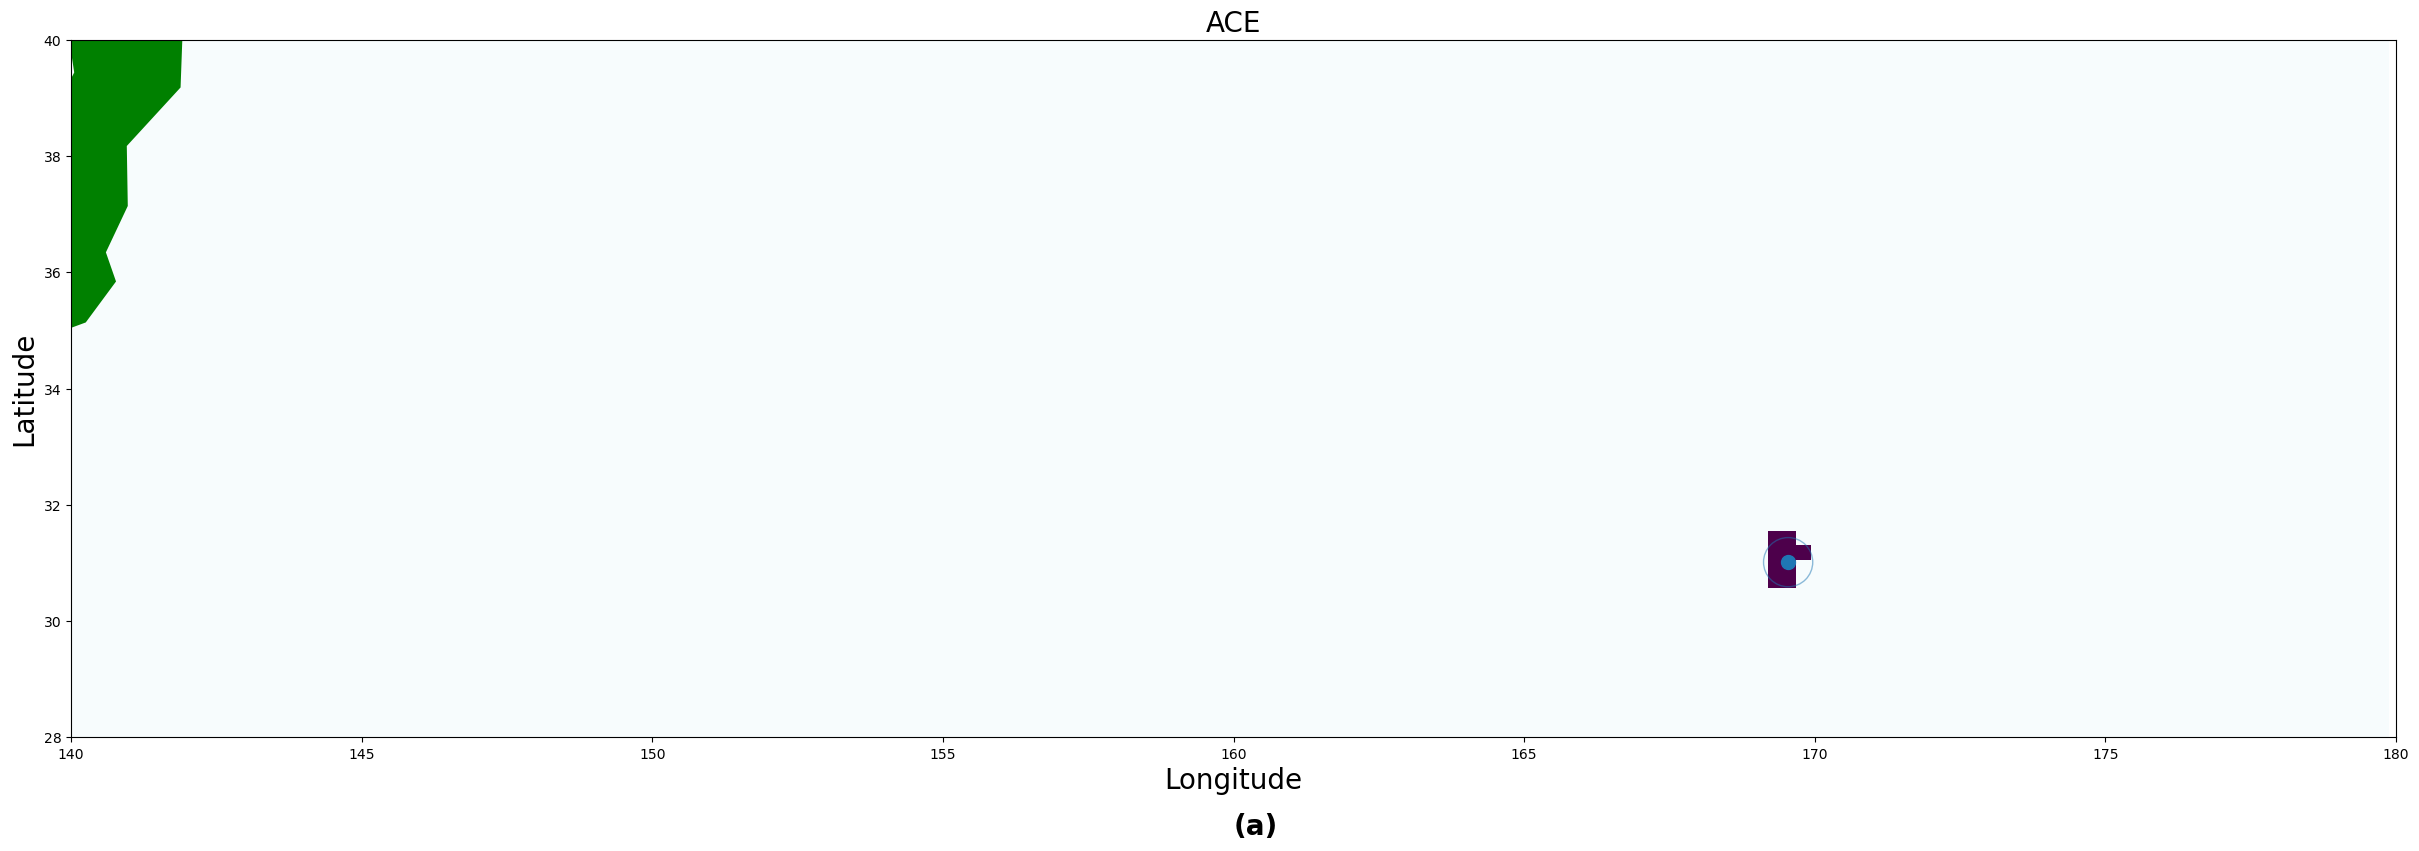

In [13]:
num=0

fig, ax = plt.subplots(figsize=(30, 20))
ax.set_title('ACE', fontsize=20)
ax.set_xlabel('Longitude', fontsize=20)
ax.set_ylabel('Latitude', fontsize=20)
ax.text(0.5, -0.14, '(a)', transform=ax.transAxes, size=20, weight='bold')
world.plot(color='green', ax=ax)
ax.scatter(data.iloc[num]['Longitude'], data.iloc[num]['Latitude'], color=colors[0], s=100, label='Point')
circle = plt.Circle((data.iloc[num]['Longitude'], data.iloc[num]['Latitude']), data.iloc[num]['R'], color=colors[0], fill=False, alpha=0.5)
ax.add_patch(circle)
img=ax.imshow(ac_area_list[num],extent=[maplon.min(), maplon.max(), maplat.min(), maplat.max()], cmap='BuPu')
ax.set_xlim([140, 180])
ax.set_ylim([28, 40])